# PRESENTATION TITLE: Convolutional Neural Networks (CNNs) with Python:

#A Case Study on the CIFAR-10 Dataset


CHUKWUDI VICTORY

11/10/24



Agenda

Introduction to Neural Network

What is a CNN?

How CNN Work?

Understanding Key Concepts

CNN Architecture Overview

Activation Functions

Working with CIFAR-10 datasets 

Practical Example: Classifying Images

Training and Evaluation

Conclusion 


# DEFINITIONS

What are Neural network?

A neural network is a computer system inspired by the way the human brain works. It's a type of artificial intelligence (AI) that can learn from data. The Neural network is the basis of Covolutional Neural Network(CNN)
The neural network is made up of three layers, The input layer,hidden layer and the output layeri 



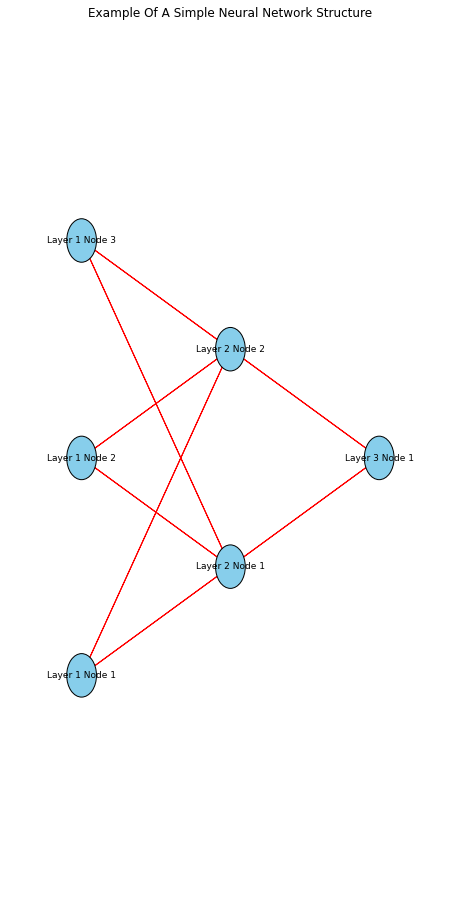

In [1]:
import matplotlib.pyplot as plt

# Function to draw a neural network
def draw_neural_network():
    # Define the layers and the number of nodes in each layer
    layers = [3, 2, 1]  # 3 input nodes, 2 hidden nodes, 1 output node
    layer_positions = [0, 1, 2]  # X positions for layers
    node_radius = 0.1  # Radius for nodes

    # Create a figure
    plt.figure(figsize=(8, 16))
    
    # Loop through layers and draw nodes
    for layer_index, num_nodes in enumerate(layers):
        for node_index in range(num_nodes):
            # Calculate the Y position for the current node
            y = node_index - (num_nodes - 1) / 2  # Center the nodes vertically
            # Draw the node
            circle = plt.Circle((layer_positions[layer_index], y), node_radius, color='skyblue', ec='black')
            plt.gca().add_artist(circle)
            # Annotate node
            plt.text(layer_positions[layer_index], y, f'Layer {layer_index + 1} Node {node_index + 1}',
                     ha='center', va='center', fontsize=9)

    # Draw arrows between nodes
    for i in range(len(layers) - 1):
        for j in range(layers[i]):
            for k in range(layers[i + 1]):
                # Draw an arrow from node in layer i to node in layer i+1
                plt.arrow(layer_positions[i], j - (layers[i] - 1) / 2,
                          layer_positions[i + 1] - layer_positions[i],
                          (k - (layers[i + 1] - 1) / 2) - (j - (layers[i] - 1) / 2),
                          head_width=0.05, head_length=0.1, fc='gray', ec='red')

    # Set limits and remove axes
    plt.xlim(-0.5, 2.5)
    plt.ylim(-2, 2)
    plt.axis('off')  # Hide axes
    plt.title('Example Of A Simple Neural Network Structure')
    plt.show()

# Call the function to draw the neural network
draw_neural_network()


## How CNNs Work

- **Key Components**:
  1. **Convolutional Layers**: Extract features from input images.
  2. **Activation Functions**: Introduce non-linearity (e.g., ReLU).
  3. **Pooling Layers**: Reduce spatial dimensions.
  4. **Fully Connected Layers**: Make final predictions.


 ## CNN Architecture Overview
- **Structure**:
  - Input Image
  - Convolutional Layer
  - Activation (ReLU)
  - Pooling Layer
  - Fully Connected Layer
  - Output
  
  A demonstration of this CNN Architecture is shown beolow

    

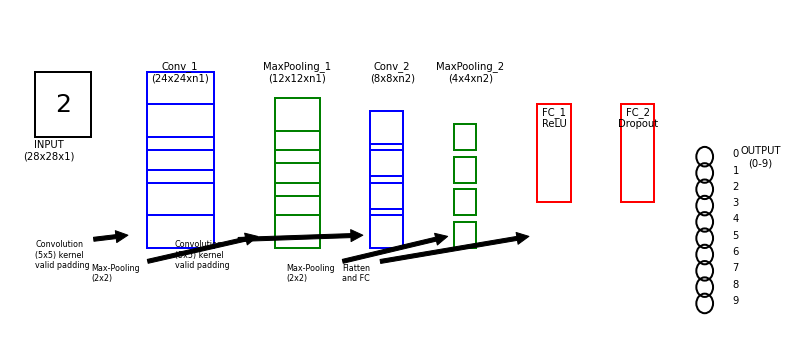

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_cnn_diagram():
    fig, ax = plt.subplots(figsize=(14, 6))

    # Draw the input image (28x28), example with the number '2'
    ax.add_patch(patches.Rectangle((0.5, 3), 1, 1, fill=None, edgecolor='black', lw=2))
    ax.text(1, 3.5, '2', fontsize=25, ha='center', va='center')  # Representing number '2' as input
    ax.text(0.75, 2.8, 'INPUT\n(28x28x1)', ha='center', va='center', fontsize=10)

    # First Convolution Layer (Conv_1 - 24x24x1)
    for i in range(4):
        ax.add_patch(patches.Rectangle((2.5, 2.8 - 0.5 * i), 1.2, 1.2, fill=None, edgecolor='blue', lw=2))
    ax.text(3.1, 4.0, 'Conv_1\n(24x24xn1)', ha='center', va='center', fontsize=10)

    # Max Pooling Layer 1 (12x12xn1)
    for i in range(4):
        ax.add_patch(patches.Rectangle((4.8, 2.8 - 0.5 * i), 0.8, 0.8, fill=None, edgecolor='green', lw=2))
    ax.text(5.2, 4.0, 'MaxPooling_1\n(12x12xn1)', ha='center', va='center', fontsize=10)

    # Second Convolution Layer (Conv_2 - 8x8xn2)
    for i in range(4):
        ax.add_patch(patches.Rectangle((6.5, 2.8 - 0.5 * i), 0.6, 0.6, fill=None, edgecolor='blue', lw=2))
    ax.text(6.9, 4.0, 'Conv_2\n(8x8xn2)', ha='center', va='center', fontsize=10)

    # Max Pooling Layer 2 (4x4xn2)
    for i in range(4):
        ax.add_patch(patches.Rectangle((8, 2.8 - 0.5 * i), 0.4, 0.4, fill=None, edgecolor='green', lw=2))
    ax.text(8.3, 4.0, 'MaxPooling_2\n(4x4xn2)', ha='center', va='center', fontsize=10)

    # Fully Connected Layer 1 (with ReLU)
    ax.add_patch(patches.Rectangle((9.5, 2.0), 0.6, 1.5, fill=None, edgecolor='red', lw=2))
    ax.text(9.8, 3.3, 'FC_1\nReLU', ha='center', va='center', fontsize=10)

    # Fully Connected Layer 2 (with Dropout)
    ax.add_patch(patches.Rectangle((11, 2.0), 0.6, 1.5, fill=None, edgecolor='red', lw=2))
    ax.text(11.3, 3.3, 'FC_2\nDropout', ha='center', va='center', fontsize=10)

    # Output Layer (10 classes)
    for i in range(10):
        ax.add_patch(patches.Circle((12.5, 2.7 - 0.25 * i), 0.15, fill=None, edgecolor='black', lw=2))
        ax.text(13.0, 2.7 - 0.25 * i, str(i), fontsize=10)
    ax.text(13.5, 2.7, 'OUTPUT\n(0-9)', ha='center', va='center', fontsize=10)

    # Annotations
    ax.annotate('Convolution\n(5x5) kernel\nvalid padding', xy=(2.2, 1.5), xytext=(0.5, 1),
                arrowprops=dict(facecolor='black', shrink=0.05), fontsize=8)
    ax.annotate('Max-Pooling\n(2x2)', xy=(4.6, 1.5), xytext=(1.5, 0.8),
                arrowprops=dict(facecolor='black', shrink=0.05), fontsize=8)
    ax.annotate('Convolution\n(5x5) kernel\nvalid padding', xy=(6.5, 1.5), xytext=(3, 1),
                arrowprops=dict(facecolor='black', shrink=0.05), fontsize=8)
    ax.annotate('Max-Pooling\n(2x2)', xy=(8, 1.5), xytext=(5, 0.8),
                arrowprops=dict(facecolor='black', shrink=0.05), fontsize=8)
    ax.annotate('Flatten\nand FC', xy=(9.5, 1.5), xytext=(6, 0.8),
                arrowprops=dict(facecolor='black', shrink=0.05), fontsize=8)

    ax.set_xlim(0, 14)
    ax.set_ylim(0, 5)
    ax.set_axis_off()

    plt.show()

# Call the function to draw the CNN diagram
draw_cnn_diagram()


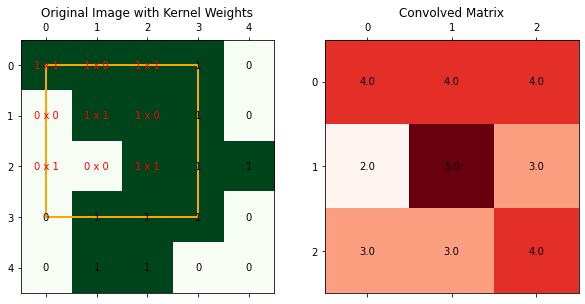

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 5x5 image (green) represented as a matrix
image = np.array([[1, 1, 1, 1, 0],
                  [0, 1, 1, 1, 0],
                  [0, 0, 1, 1, 1],
                  [0, 1, 1, 1, 0],
                  [0, 1, 1, 0, 0]])

# 3x3 kernel with weights (yellow)
kernel = np.array([[1, 0, 1],
                   [0, 1, 0],
                   [1, 0, 1]])

# Function to perform convolution
def convolve(image, kernel):
    # Image size is 5x5 and kernel size is 3x3
    image_size = image.shape[0]
    kernel_size = kernel.shape[0]
    output_size = image_size - kernel_size + 1  # Size of the convolved output

    # Output matrix to store convolved values
    convolved_output = np.zeros((output_size, output_size))

    # Convolve the kernel over the image
    for i in range(output_size):
        for j in range(output_size):
            region = image[i:i+kernel_size, j:j+kernel_size]  # Extract 3x3 region from the image
            convolved_output[i, j] = np.sum(region * kernel)  # Element-wise multiplication and sum
    return convolved_output

# Perform convolution
convolved_result = convolve(image, kernel)

# Plotting
def plot_convolution_with_weights(image, kernel, convolved_result):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Plot the image matrix with a highlighted kernel region
    ax1.matshow(image, cmap='Greens')

    # Highlight the kernel's first position on the image (top-left)
    rect = patches.Rectangle((0, 0), 3, 3, linewidth=2, edgecolor='orange', facecolor='none')
    ax1.add_patch(rect)

    # Add values to the image matrix with red multiplications
    for i in range(3):
        for j in range(3):
            ax1.text(j, i, f'{image[i, j]} x {kernel[i, j]}', ha='center', va='center', color='red')

    # Add values to the rest of the image matrix (non-kernel region)
    for i in range(3, 5):
        for j in range(5):
            ax1.text(j, i, f'{image[i, j]}', ha='center', va='center')

    for i in range(3):
        for j in range(3, 5):
            ax1.text(j, i, f'{image[i, j]}', ha='center', va='center')

    ax1.set_title('Original Image with Kernel Weights')

    # Plot the convolved result
    ax2.matshow(convolved_result, cmap='Reds')

    # Add values to the convolved matrix
    for (i, j), val in np.ndenumerate(convolved_result):
        ax2.text(j, i, f'{val}', ha='center', va='center')

    ax2.set_title('Convolved Matrix')

    plt.show()

# Plot the convolution process with weights
plot_convolution_with_weights(image, kernel, convolved_result)


Here we have a  5x5 image which is represented in green with some pixel values such as 0 and 1. the convolution is actually the kernel so its this 3x3 yellow squares which goes around the image thats a kernel and thats the process of convolution. You can see the red numbers on the image times 1 or 0 those are the weights of the kernel the neural network needs to learn in order to extract meaningful features from the image.


# Working with CIFAR-10 datasets  

CIFAR-10 Dataset Overview

What is CIFAR-10?

A popular dataset for image classification.
Contains 60,000 32x32 color images in 10 different classes (e.g., airplanes, cars, birds, etc.).
Each class has 6,000 images, with 50,000 for training and 10,000 for testing.
Classes in CIFAR-10:

Airplane
Automobile
Bird
Cat
Deer
Dog
Frog
Horse
Ship
Truck
 Basic Structure of a CNN
Components of a CNN:

Convolutional Layers: Extract features from images.
Activation Functions: Introduce non-linearity (e.g., ReLU).
Pooling Layers: Downsample the feature maps (e.g., max pooling).
Fully Connected Layers: Classify the features.
Flow of Data:

Input Image → Convolution → Activation → Pooling → Fully Connected → Output Classification.
Slide 4: Setting Up the Environment

#Required Libraries:
Python
TensorFlow/Keras
NumPy
Matplotlib (for visualization)

No Bottleneck unit testing available.


/home/aldino/.local/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.3520 - loss: 1.7452 - val_accuracy: 0.5478 - val_loss: 1.2640
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5584 - loss: 1.2308 - val_accuracy: 0.6109 - val_loss: 1.0907
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6259 - loss: 1.0615 - val_accuracy: 0.6448 - val_loss: 0.9962
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6671 - loss: 0.9419 - val_accuracy: 0.6743 - val_loss: 0.9358
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7021 - loss: 0.8523 - val_accuracy: 0.6798 - val_loss: 0.9116
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7284 - loss: 0.7811 - val_accuracy: 0.6931 - val_loss: 0.8956
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7378 - loss: 0.7456 - val_accuracy: 0.6951 - val_loss: 0.8876
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7586 -

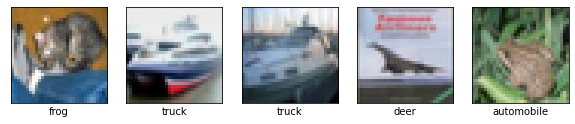

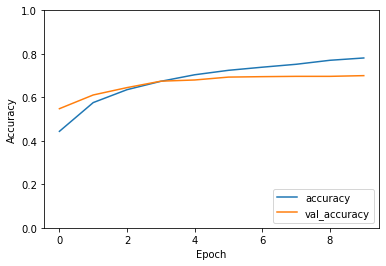

In [4]:
# Building a CNN for CIFAR-10
#Step 1: Import Libraries and Load Dataset
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize the pixel values to range 0-1
train_images, test_images = train_images / 255.0, test_images / 255.0
model = models.Sequential()

# First Convolutional layer + Pooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Second Convolutional layer + Pooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Third Convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Flatten the feature maps and add Fully Connected Layer
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))  # 10 output units for the 10 classes
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

import matplotlib.pyplot as plt
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Show the first 5 test images with their predicted labels
plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(test_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20, 
    width_shift_range=0.2, 
    height_shift_range=0.2, 
    horizontal_flip=True)
datagen.fit(train_images)
model.add(layers.Dropout(0.5))



Let's break down the function of this code, step by step, in a way that a beginner can easily understand.
We are building a Convolutional Neural Network (CNN) for recognizing images in the CIFAR-10 dataset, which contains pictures of objects like airplanes, cars, and animals. CNNs are great at recognizing patterns in images.

Code Breakdown
1. Importing Libraries and Loading the CIFAR-10 Dataset

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt


# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
TensorFlow is the main tool we're using to build the neural network.
datasets.cifar10.load_data(): This command loads the CIFAR-10 dataset, which includes pictures of 10 different categories (like airplanes, birds, and cats). The dataset is split into two parts:
train_images and train_labels: Images and their correct labels that we use to train the network.
test_images and test_labels: Images and labels that we use to test how well the network learned.
2. Normalizing the Images

# Normalize the pixel values to range 0-1

train_images, test_images = train_images / 255.0, test_images / 255.0
Why Normalize?: Images are made of pixels, and each pixel has a value between 0 and 255 (this represents the color intensity). By dividing by 255, we scale the pixel values to a range between 0 and 1, which makes it easier for the network to process.
3. Building the Model
model = models.Sequential()
models.Sequential(): This creates a Sequential Model, which means we are building our neural network layer by layer, like stacking blocks one on top of the other.
4. Adding the First Convolutional Layer and Pooling

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
First Convolutional Layer (Conv2D):

Conv2D(32, (3, 3)): This is a Convolutional Layer, which is like a small window that slides over the image, looking for patterns such as edges or shapes.
32 means we’re creating 32 filters (or windows), each looking for different patterns.
(3, 3) means that each filter is a small 3x3 window.
activation='relu': This is a function that helps the network decide which patterns are important by turning negative values to zero, making the output simpler and more efficient to process.
input_shape=(32, 32, 3): This tells the network the shape of the input images—32 pixels wide, 32 pixels high, and 3 color channels (red, green, and blue).
MaxPooling2D((2, 2)): After the convolutional layer, we apply Max Pooling. Pooling reduces the size of the image but keeps the important information. It looks at 2x2 areas in the image and keeps the brightest spot (the biggest number). This helps the model learn faster.

5. Adding the Second Convolutional Layer and Pooling

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
Second Convolutional Layer (Conv2D):
Conv2D(64, (3, 3)): This is another convolutional layer, but this time it has 64 filters instead of 32, so it can detect more complex patterns. As the network goes deeper, it learns more detailed and abstract features of the images.
MaxPooling2D((2, 2)): Again, we reduce the size of the image with pooling, keeping only the important parts.
6. Adding the Third Convolutional Layer

# Third Convolutional Layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
Third Convolutional Layer (Conv2D):
Conv2D(64, (3, 3)): This is another convolutional layer with 64 filters, just like the second one. By this stage, the network has already identified basic features like edges and simple shapes from the previous layers. Now, it’s looking for even more detailed patterns in the images, such as textures or smaller parts of objects.


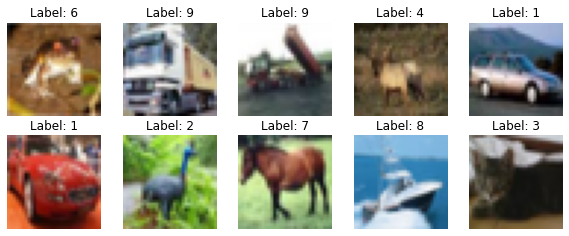

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.3450 - loss: 1.7506 - val_accuracy: 0.5386 - val_loss: 1.2657
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.5694 - loss: 1.2050 - val_accuracy: 0.6093 - val_loss: 1.0985
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6402 - loss: 1.0153 - val_accuracy: 0.6535 - val_loss: 0.9760
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6799 - loss: 0.9117 - val_accuracy: 0.6768 - val_loss: 0.9159
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7070 - loss: 0.8321 - val_accuracy: 0.6947 - val_loss: 0.8611
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7302 - loss: 0.7722 - val_accuracy: 0.7023 - val_loss: 0.8630
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7502 - loss: 0.7182 - val_accuracy: 0.7047 - val_loss: 0.8428
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7623 -

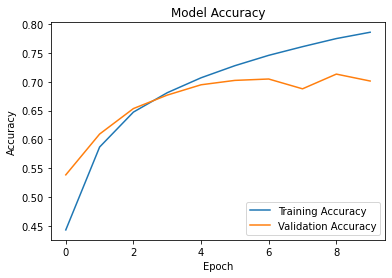

In [5]:
import tensorflow as tf
from tensorflow.keras import datasets

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0
import matplotlib.pyplot as plt

# Plot 10 random images from the training set
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(f'Label: {y_train[i][0]}')
    plt.axis('off')
plt.show()
from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes for CIFAR-10
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Train the model
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()



Conclusion
Key Takeaways:

CNNs are powerful tools for image classification tasks.
The CIFAR-10 dataset provides a solid foundation for understanding CNNs.
Python and TensorFlow/Keras make it easy to implement and train CNN models.
